In [1]:
import numpy as np
import geopandas as gpd

In [2]:
df = gpd.read_file('../output/Arkansas/Arkansas_precincts_topo.topojson')

In [3]:
df.head()

,id,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry
0,0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,876.242147,40.697081,3.735137,0.084330,"MULTIPOLYGON (((-91.52312 34.47879, -91.52342 ..."
1,1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,77.286145,13.670368,1.271662,2.864170,"POLYGON ((-91.38939 34.11621, -91.38765 34.116..."
2,2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,368.305262,36.126328,0.032546,1.298186,"POLYGON ((-91.32907 34.28235, -91.3327 34.2822..."
3,3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,541.583568,37.255966,0.000000,1.310622,"POLYGON ((-91.32907 34.28235, -91.32907 34.282..."
4,4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,46.173247,19.513668,1.544880,0.610693,"POLYGON ((-91.34061 34.30203, -91.34061 34.300..."


0.0     0.000000
0.1     0.000000
0.2     0.000214
0.3     0.261916
0.4     1.062584
0.5     2.263825
0.6     5.295316
0.7    11.808977
0.8    23.727387
0.9    47.143514
1.0    99.979859
Name: black_percentage, dtype: float64


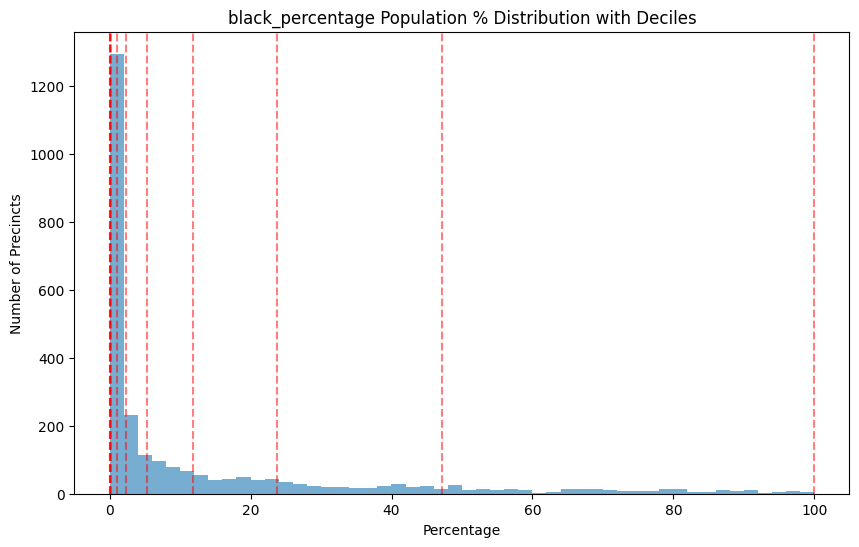

0.0     0.000000
0.1     0.000231
0.2     0.355436
0.3     1.071764
0.4     1.789961
0.5     2.546110
0.6     3.583789
0.7     4.884013
0.8     6.976812
0.9    10.560816
1.0    73.320317
Name: latino_percentage, dtype: float64


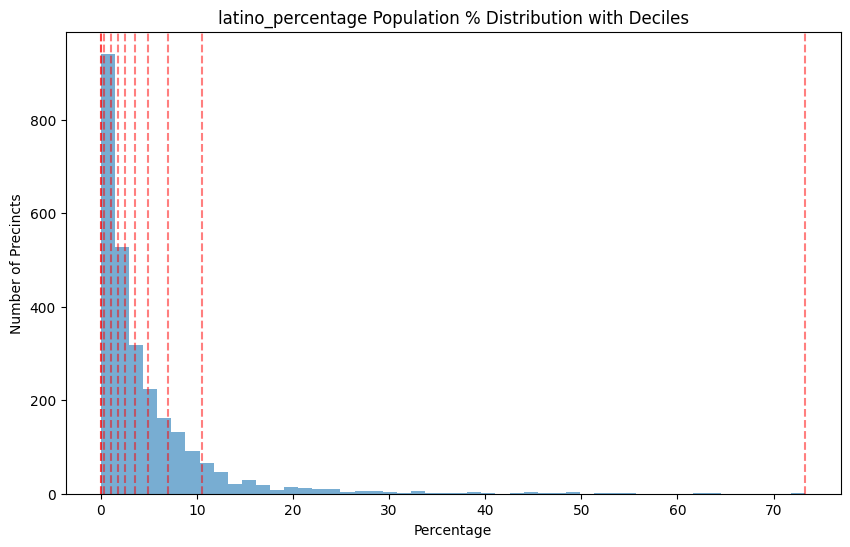

0.0     0.000000
0.1     0.615765
0.2     1.301416
0.3     1.948792
0.4     2.568302
0.5     3.343745
0.6     4.071330
0.7     5.033892
0.8     6.480850
0.9     8.816103
1.0    28.206660
Name: other_percentage, dtype: float64


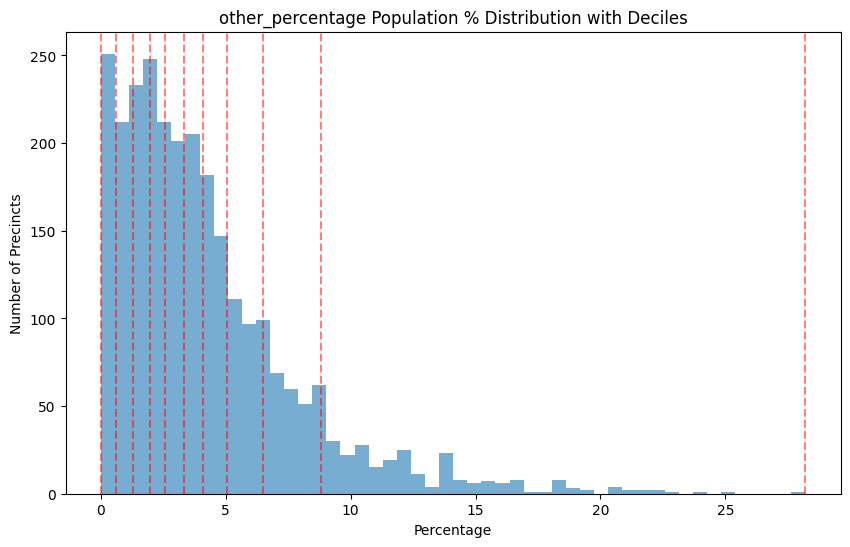

In [4]:
import matplotlib.pyplot as plt

races = ['black_percentage', 'latino_percentage', 'other_percentage']
for col in races:
    values = df[col]
    if values.isna().sum() > 0:
        print(f"{col} has nan")
    deciles = df[col].quantile(np.linspace(0, 1, 11))
    print(deciles)

    plt.figure(figsize=(10,6))

    plt.hist(values, bins=50, alpha=0.6)

    # draw vertical lines for deciles
    for d in deciles:
        plt.axvline(d, color="red", linestyle="--", alpha=0.5)

    plt.title(f"{col} Population % Distribution with Deciles")
    plt.xlabel("Percentage")
    plt.ylabel("Number of Precincts")
    plt.show()

In [5]:
import mapclassify
races = ['black', 'latino', 'other']
legend = {}
for race in races:
    values = df[f"{race}_percentage"]
    classifier = mapclassify.Quantiles(values, k=6)
    df[f"{race}_bin"] = classifier.yb
    legend[race] = {
        "bins": classifier.bins.tolist(),
        "min": float(values.min()),
        "max": float(values.max())
    }
    print(f"{race} bins: {classifier.bins}")
    
legend


black bins: [1.00182985e-05 4.42100909e-01 2.26382496e+00 9.43871417e+00
 2.96691318e+01 9.99798592e+01]
latino bins: [ 0.12469691  1.34554498  2.54610983  4.39930268  7.93445845 73.32031681]
other bins: [ 1.08792318  2.15340976  3.34374487  4.64417119  7.03951675 28.20665965]


{'black': {'bins': [1.0018298526022712e-05,
   0.44210090902758814,
   2.263824957735059,
   9.43871416983293,
   29.669131835256202,
   99.97985918756177],
  'min': 0.0,
  'max': 99.97985918756177},
 'latino': {'bins': [0.12469691004932174,
   1.3455449823731145,
   2.5461098311430876,
   4.39930267654168,
   7.934458446701804,
   73.32031680732018],
  'min': 0.0,
  'max': 73.32031680732018},
 'other': {'bins': [1.087923177282048,
   2.1534097630318616,
   3.34374486502802,
   4.644171192402073,
   7.039516746553135,
   28.20665965275822],
  'min': 0.0,
  'max': 28.20665965275822}}

In [6]:
import json
with open("../output/Arkansas/Arkansas_legend.json", "w") as f:
    json.dump(legend, f)

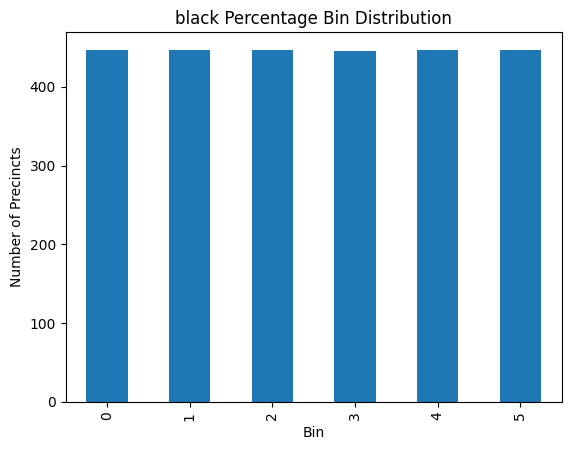

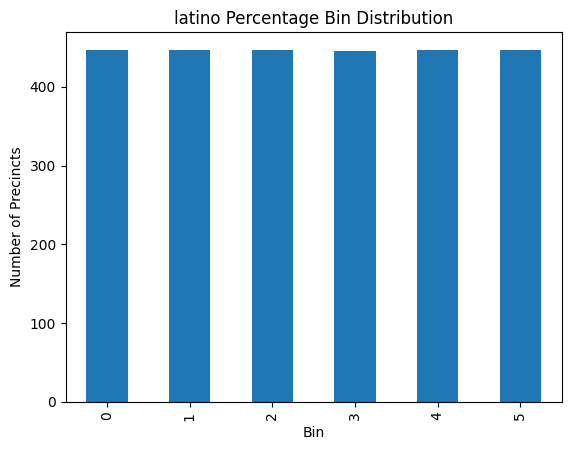

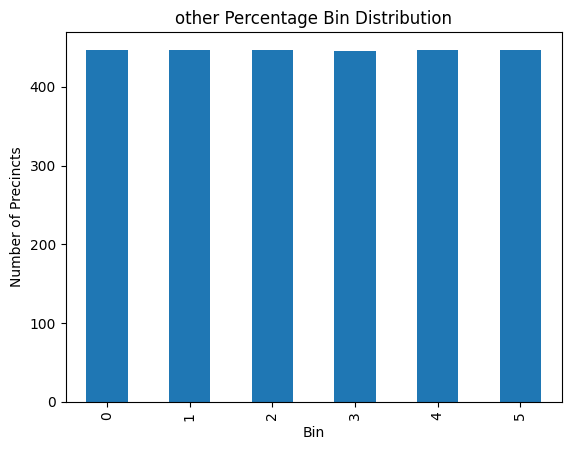

In [7]:
for race in races:
    df[f"{race}_bin"].value_counts().sort_index().plot(kind="bar")

    plt.title(f"{race} Percentage Bin Distribution")
    plt.xlabel("Bin")
    plt.ylabel("Number of Precincts")
    plt.show()

In [8]:
df['precinct'] = 'Precinct ' + df['precinct']
df.head()

,id,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry,black_bin,latino_bin,other_bin
0,0,05001-81 - Stuttgart 2,Precinct 05001-81 - Stuttgart 2,876.242147,40.697081,3.735137,0.084330,"MULTIPOLYGON (((-91.52312 34.47879, -91.52342 ...",5,3,0
1,1,05001-36 - Gillett Ward 3,Precinct 05001-36 - Gillett Ward 3,77.286145,13.670368,1.271662,2.864170,"POLYGON ((-91.38939 34.11621, -91.38765 34.116...",4,1,2
2,2,05001-53 - Dewitt 2,Precinct 05001-53 - Dewitt 2,368.305262,36.126328,0.032546,1.298186,"POLYGON ((-91.32907 34.28235, -91.3327 34.2822...",5,0,1
3,3,05001-51 - DeWitt 1,Precinct 05001-51 - DeWitt 1,541.583568,37.255966,0.000000,1.310622,"POLYGON ((-91.32907 34.28235, -91.32907 34.282...",5,0,1
4,4,05001-55 - Dewitt 3,Precinct 05001-55 - Dewitt 3,46.173247,19.513668,1.544880,0.610693,"POLYGON ((-91.34061 34.30203, -91.34061 34.300...",4,2,0


In [9]:
import topojson as tp
topo = tp.Topology(df, prequantize=True)
topo.to_json("../output/Arkansas/Arkansas_precincts_topo.topojson")